# Economic Data Analysis with Pandas 
from [Youtube] (https://www.youtube.com/watch?v=R67XuYc9NQ4)

Set up api key in .env file
Be sure to use .gitignore to exlude .env file



In [52]:
from dotenv import load_dotenv
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import time

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

from fredapi import Fred

load_dotenv()

api_key = os.getenv("FRED_API_KEY")

# Fred Object
fred = Fred(api_key=api_key)

In [53]:
print("Key loaded:", api_key is not None)

Key loaded: True


### Search for economic data

In [54]:
sp_search = fred.search("S&P 500", order_by="popularity", limit=5)

In [55]:
sp_search.shape

(5, 15)

In [56]:
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
SP500,SP500,2026-03-12,2026-03-12,S&P 500,2016-03-14,2026-03-11,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-11 19:01:52-05:00,90,The observations for the S&P 500 represent the...
MEHOINUSA646N,MEHOINUSA646N,2026-03-12,2026-03-12,Median Household Income in the United States,1984-01-01,2024-01-01,Annual,A,Current Dollars,Current $,Not Seasonally Adjusted,NSA,2025-09-09 13:19:03-05:00,72,Household data are collected as of March. As ...
VXVCLS,VXVCLS,2026-03-12,2026-03-12,CBOE S&P 500 3-Month Volatility Index,2007-12-04,2026-03-11,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-12 08:37:30-05:00,61,"Copyright, 2016, Chicago Board Options Exchang..."
MEHOINUSCAA646N,MEHOINUSCAA646N,2026-03-12,2026-03-12,Median Household Income in California,1984-01-01,2024-01-01,Annual,A,Current Dollars,Current $,Not Seasonally Adjusted,NSA,2025-09-09 13:19:04-05:00,51,Household data are collected as of March. As ...
EMVOVERALLEMV,EMVOVERALLEMV,2026-03-12,2026-03-12,Equity Market Volatility Tracker: Overall,1985-01-01,2026-02-01,Monthly,M,Index,Index,Not Seasonally Adjusted,NSA,2026-03-04 08:02:55-06:00,48,The Equity Market Volatility tracker moves wit...


### 3. Pull Raw Data & Plot

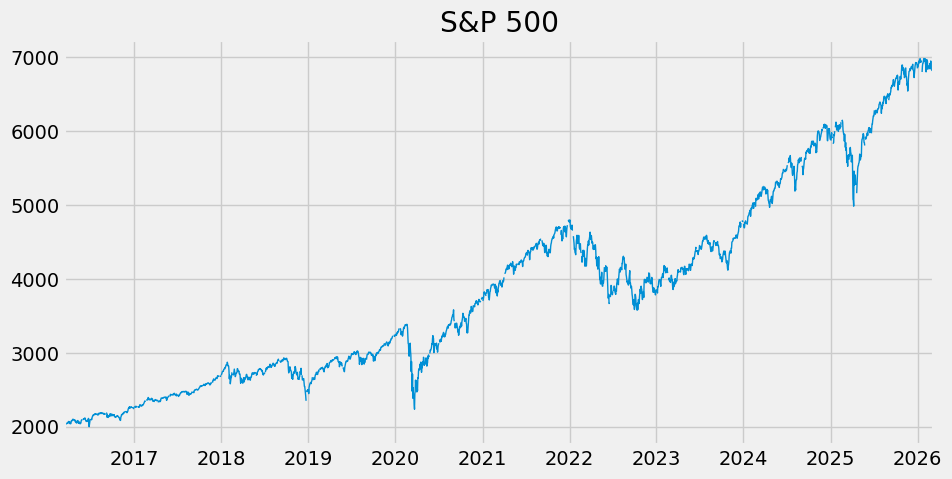

In [57]:
sp500 = fred.get_series(series_id='SP500')
sp500.plot(figsize=(10, 5), title='S&P 500', lw=1)
plt.show()

### 4. Pull and Join Multiple Data Series


In [58]:
uemp_results = fred.search('unemployment')
uemp_results 

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,74,The series comes from the 'Current Population ...
NROU,NROU,2026-03-12,2026-03-12,Noncyclical Rate of Unemployment,1949-01-01,2036-10-01,Quarterly,Q,Percent,%,Not Seasonally Adjusted,NSA,2026-02-27 15:05:27-06:00,69,"Starting with the July, 2021 report: An Update..."
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENUC120640510SA,ENUC120640510SA,2026-03-12,2026-03-12,Average Weekly Wages for Employees in Private ...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Seasonally Adjusted,SA,2026-03-10 11:32:31-05:00,1,Average weekly wages are the wages paid by une...
ENUC455040210,ENUC455040210,2026-03-12,2026-03-12,Average Weekly Wages for Employees in State Go...,1990-01-01,2025-04-01,Quarterly,Q,Dollars per Week,$ per Week,Not Seasonally Adjusted,NSA,2025-12-19 11:20:23-06:00,1,Average weekly wages are the wages paid by une...
ENUC455040210SA,ENUC455040210SA,2026-03-12,2026-03-12,Average Weekly Wages for Employees in State Go...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Seasonally Adjusted,SA,2026-03-10 11:27:51-05:00,1,Average weekly wages are the wages paid by une...


In [59]:
unrate = fred.get_series('unrate')

<Axes: >

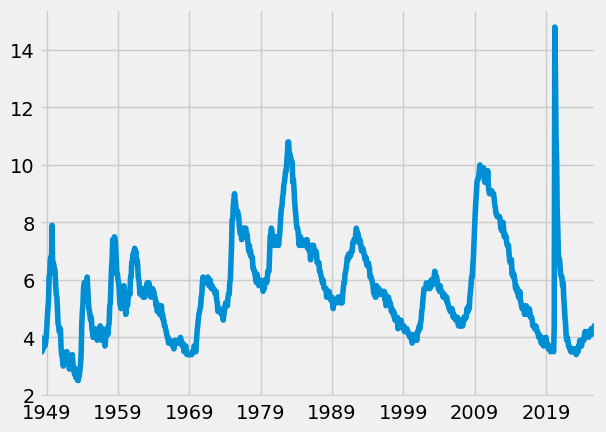

In [60]:
unrate.plot()

In [61]:
fred.search('unemployment rate state', filter=('frequency', 'Monthly'))

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,74,The series comes from the 'Current Population ...
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
LNU03000000,LNU03000000,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-03-06 08:14:10-06:00,29,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAUCN361190000000005,LAUCN361190000000005,2026-03-12,2026-03-12,"Employed Persons in Westchester County, NY",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:18:54-06:00,1,These data come from the Current Population Su...
LAUCN515100000000005,LAUCN515100000000005,2026-03-12,2026-03-12,"Employed Persons in Alexandria City, VA",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:15:42-06:00,1,These data come from the Current Population Su...
NDDUNN5LFN,NDDUNN5LFN,2026-03-12,2026-03-12,"Civilian Labor Force in Dunn County, ND",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:13:20-06:00,1,These data come from the Current Population Su...


In [62]:
unemp_df = fred.search('unemployment rate state', filter=('frequency','Monthly'))

In [64]:
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
unemp_df  

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
LNS14000006,LNS14000006,2026-03-12,2026-03-12,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,69,The series comes from the 'Current Population ...
CAUR,CAUR,2026-03-12,2026-03-12,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,65,NaN
LNS14024887,LNS14024887,2026-03-12,2026-03-12,Unemployment Rate - 16-24 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:48-06:00,62,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INUR,INUR,2026-03-12,2026-03-12,Unemployment Rate in Indiana,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:59-06:00,29,NaN
NDUR,NDUR,2026-03-12,2026-03-12,Unemployment Rate in North Dakota,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:46-06:00,28,NaN
ARUR,ARUR,2026-03-12,2026-03-12,Unemployment Rate in Arkansas,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:22-06:00,28,NaN


In [65]:
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]
unemp_df 


,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
LNS14000006,LNS14000006,2026-03-12,2026-03-12,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,69,The series comes from the 'Current Population ...
CAUR,CAUR,2026-03-12,2026-03-12,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,65,NaN
LNS14024887,LNS14024887,2026-03-12,2026-03-12,Unemployment Rate - 16-24 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:48-06:00,62,The series comes from the 'Current Population ...
LNS14000024,LNS14000024,2026-03-12,2026-03-12,Unemployment Rate - 20 Yrs. & over,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:50-06:00,58,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LNS14000089,LNS14000089,2026-03-12,2026-03-12,Unemployment Rate - 25-34 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,29,The series comes from the 'Current Population ...
INUR,INUR,2026-03-12,2026-03-12,Unemployment Rate in Indiana,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:59-06:00,29,NaN
NDUR,NDUR,2026-03-12,2026-03-12,Unemployment Rate in North Dakota,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:46-06:00,28,NaN


In [66]:
unemp_df.index



Index(['UNRATE', 'LNS14000006', 'CAUR', 'LNS14024887', 'LNS14000024', 'TXUR',
       'LNS14027662', 'M0892AUSM156SNBR', 'NYUR', 'M0892BUSM156SNBR', 'FLUR',
       'LNS14000002', 'ALUR', 'LNS14000003', 'ILUR', 'GAUR', 'LNS14000036',
       'LNS14027660', 'U2RATE', 'LNS14000009', 'MIUR', 'OHUR', 'MSUR',
       'LNS14000001', 'PAUR', 'LAUR', 'LNS14000012', 'MAUR', 'VAUR', 'MNUR',
       'NJUR', 'KYUR', 'LNS14000060', 'MOUR', 'NCUR', 'ORUR', 'LNS14027659',
       'DCUR', 'WIUR', 'LNS14000032', 'COUR', 'NVUR', 'TNUR', 'AKUR', 'SCUR',
       'MDUR', 'AZUR', 'LNS14000031', 'LASMT261982000000003', 'PRUR', 'WAUR',
       'WVUR', 'IAUR', 'LASMT534266000000003', 'UTUR', 'CTUR', 'LNS14032183',
       'HIUR', 'NMUR', 'LNS14000089', 'INUR', 'NDUR', 'ARUR', 'OKUR'],
      dtype='str', name='series id')

In [67]:
for myid in unemp_df.index:
    results = fred.get_series(myid)
    break

In [70]:
results.to_frame(name=myid) 

,UNRATE
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5
...,...
2025-10-01,NaN
2025-11-01,4.5
2025-12-01,4.4
2026-01-01,4.3


In [76]:
all_results = []

for myid in unemp_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)
    all_results.append(results)
    time.sleep(0.1) # Don't request to fast and get blocked
uemp_results = pd.concat(all_results, axis=1, sort=False)

In [73]:
type(all_results)

list

In [75]:
all_results[4]

,LNS14000024
1948-01-01,3.0
1948-02-01,3.3
1948-03-01,3.5
1948-04-01,3.5
1948-05-01,3.3
...,...
2025-10-01,NaN
2025-11-01,4.1
2025-12-01,3.9
2026-01-01,4.0


In [77]:
uemp_results 

,UNRATE,LNS14000006,CAUR,LNS14024887,LNS14000024,TXUR,LNS14027662,M0892AUSM156SNBR,NYUR,M0892BUSM156SNBR,FLUR,LNS14000002,ALUR,LNS14000003,ILUR,GAUR,LNS14000036,LNS14027660,U2RATE,LNS14000009,MIUR,OHUR,MSUR,LNS14000001,PAUR,LAUR,LNS14000012,MAUR,VAUR,MNUR,NJUR,KYUR,LNS14000060,MOUR,NCUR,ORUR,LNS14027659,DCUR,WIUR,LNS14000032,COUR,NVUR,TNUR,AKUR,SCUR,MDUR,AZUR,LNS14000031,LASMT261982000000003,PRUR,WAUR,WVUR,IAUR,LASMT534266000000003,UTUR,CTUR,LNS14032183,HIUR,NMUR,LNS14000089,INUR,NDUR,ARUR,OKUR
1948-01-01,3.4,NaN,NaN,6.8,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.3,NaN,NaN,NaN,NaN,5.8,NaN,NaN,NaN,NaN,NaN,NaN,3.4,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
1948-02-01,3.8,NaN,NaN,7.7,3.3,NaN,NaN,NaN,NaN,NaN,NaN,4.5,NaN,NaN,NaN,NaN,6.3,NaN,NaN,NaN,NaN,NaN,NaN,3.6,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.3,NaN,NaN,NaN,NaN
1948-03-01,4.0,NaN,NaN,8.7,3.5,NaN,NaN,NaN,NaN,NaN,NaN,4.4,NaN,NaN,NaN,NaN,7.6,NaN,NaN,NaN,NaN,NaN,NaN,3.8,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.9,NaN,NaN,NaN,NaN
1948-04-01,3.9,NaN,NaN,7.8,3.5,NaN,NaN,NaN,NaN,NaN,NaN,4.3,NaN,NaN,NaN,NaN,6.8,NaN,NaN,NaN,NaN,NaN,NaN,3.8,NaN,NaN,9.5,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.4,NaN,NaN,NaN,NaN
1948-05-01,3.5,NaN,NaN,6.7,3.3,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,6.6,NaN,NaN,NaN,NaN,NaN,NaN,3.5,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
uemp_results

(1151, 64)

Filter for state level unemployment rates.  Pattern for series [State_abbreviation]UR

In [80]:
state_cols = [c for c in uemp_results.columns if c.endswith("UR")]

state_unemployment = uemp_results[state_cols]

In [81]:
state_unemployment.head()

,CAUR,TXUR,NYUR,FLUR,ALUR,ILUR,GAUR,MIUR,OHUR,MSUR,PAUR,LAUR,MAUR,VAUR,MNUR,NJUR,KYUR,MOUR,NCUR,ORUR,DCUR,WIUR,COUR,NVUR,TNUR,AKUR,SCUR,MDUR,AZUR,PRUR,WAUR,WVUR,IAUR,UTUR,CTUR,HIUR,NMUR,INUR,NDUR,ARUR,OKUR
1948-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
